## Megabench msr comparison

In [1]:
megabench_error_data_path = "../data/15-12-05"
megabench_no_error_data_path = "../data/10-49-18"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sys
import os 
import yaml
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.plots import *


error_caterpillar_cat_path = f"{megabench_error_data_path}/caterpillar_cat.csv"
error_caterpillar_no_cat_path = f"{megabench_error_data_path}/caterpillar_no_cat.csv"
error_cyclictest_cat_path = f"{megabench_error_data_path}/cyclictest_cat.csv"
error_cyclictest_no_cat_path = f"{megabench_error_data_path}/cyclictest_no_cat.csv"

no_error_caterpillar_cat_path = f"{megabench_no_error_data_path}/caterpillar_cat.csv"
no_error_caterpillar_no_cat_path = f"{megabench_no_error_data_path}/caterpillar_no_cat.csv"
no_error_cyclictest_cat_path = f"{megabench_no_error_data_path}/cyclictest_cat.csv"
no_error_cyclictest_no_cat_path = f"{megabench_no_error_data_path}/cyclictest_no_cat.csv"

In [3]:
! cat ../data/10-49-18/output.csv | grep -i "error"

/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: echo: echo: I/O error
/bin/sh: 1: ec

In [4]:
error_cater_cat_df = pd.read_csv(error_caterpillar_cat_path)
error_cater_no_cat_df = pd.read_csv(no_error_caterpillar_no_cat_path)
no_error_cater_no_cat_df = pd.read_csv(no_error_caterpillar_cat_path)
no_error_cater_cat_df = pd.read_csv(no_error_caterpillar_cat_path)

error_cater_cat_df['CAT'] = True
error_cater_cat_df['MSR'] = False

error_cater_no_cat_df['CAT'] = False
error_cater_no_cat_df['MSR'] = False

no_error_cater_no_cat_df['CAT'] = False
no_error_cater_no_cat_df['MSR'] = True

no_error_cater_cat_df['CAT'] = True
no_error_cater_cat_df['MSR'] = True

caterpillar_df = pd.concat([
    error_cater_cat_df,
    error_cater_no_cat_df,
    no_error_cater_no_cat_df,
    no_error_cater_cat_df
], ignore_index=True)

In [5]:
caterpillar_df

,timestamp,SampleMin,SampleMax,SmplJitter,SessionMin,SessionMax,SessionJitter,Sample,CAT,MSR
0,2025-11-07 17:32:17,278336,33644780,334249,278336,33644780,334249,0,True,False
1,2025-11-07 17:32:18,278296,155494100,1551940,278296,155494100,1122540,1,True,False
2,2025-11-07 17:32:19,278280,392700,14691,278280,155494100,916565,2,True,False
3,2025-11-07 17:32:20,278334,155521570,1552262,278280,155521570,1110125,3,True,False
4,2025-11-07 17:32:21,278344,154356542,1540412,278280,155521570,1208509,4,True,False
...,...,...,...,...,...,...,...,...,...,...
28795,2025-11-10 15:29:09,289470,154632928,2180043,278064,157004216,1607662,7195,True,True
28796,2025-11-10 15:29:10,278970,154425648,1541260,278064,157004216,1607653,7196,True,True
28797,2025-11-10 15:29:11,280102,154442400,1541421,278064,157004216,1607644,7197,True,True
28798,2025-11-10 15:29:12,278818,154153100,1538482,278064,157004216,1607634,7198,True,True


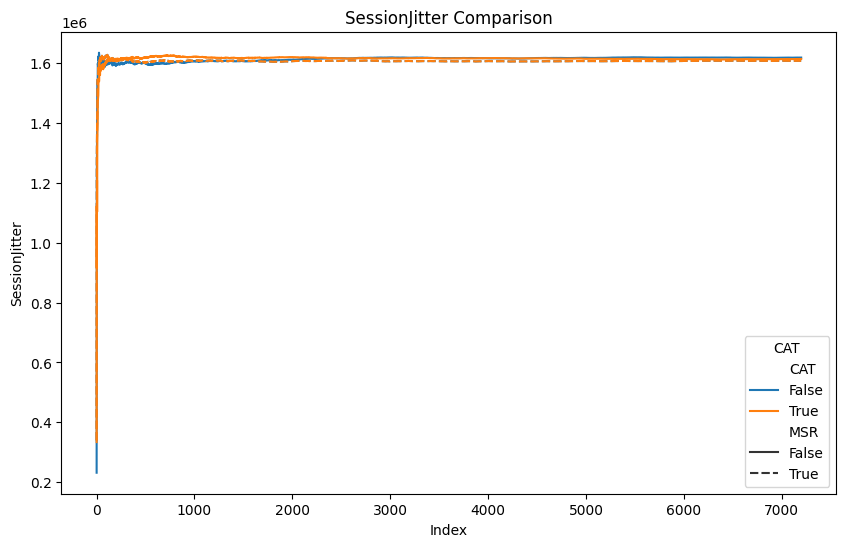

In [6]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=caterpillar_df, x='Sample', y='SessionJitter', hue='CAT', style="MSR")
plt.title('SessionJitter Comparison')
plt.xlabel('Index')
plt.ylabel('SessionJitter')
plt.legend(title='CAT')
plt.show()

In [16]:
error_cyclictest_cat = pd.read_csv(error_cyclictest_cat_path) 
error_cyclictest_no_cat = pd.read_csv(error_cyclictest_no_cat_path) 
no_error_cyclictest_cat = pd.read_csv(no_error_cyclictest_cat_path) 
no_error_cyclictest_no_cat = pd.read_csv(no_error_cyclictest_no_cat_path) 

cnt_e_c = error_cyclictest_cat['Act'].value_counts().sort_index().reset_index()
cnt_e_c.columns = ['Microseconds', 'Count']
cnt_e_c['Mode'] = 'With Error With CAT'

cnt_e_nc = error_cyclictest_no_cat['Act'].value_counts().sort_index().reset_index()
cnt_e_nc.columns = ['Microseconds', 'Count']
cnt_e_nc['Mode'] = 'With Error No CAT'


cnt_ne_nc = no_error_cyclictest_no_cat['Act'].value_counts().sort_index().reset_index()
cnt_ne_nc.columns = ['Microseconds', 'Count']
cnt_ne_nc['Mode'] = 'No Error No CAT'

cnt_ne_c = no_error_cyclictest_cat['Act'].value_counts().sort_index().reset_index()
cnt_ne_c.columns = ['Microseconds', 'Count']
cnt_ne_c['Mode'] = 'No Error With CAT'

In [17]:
combined = pd.concat([cnt_e_c, cnt_e_nc, cnt_ne_nc, cnt_ne_c])

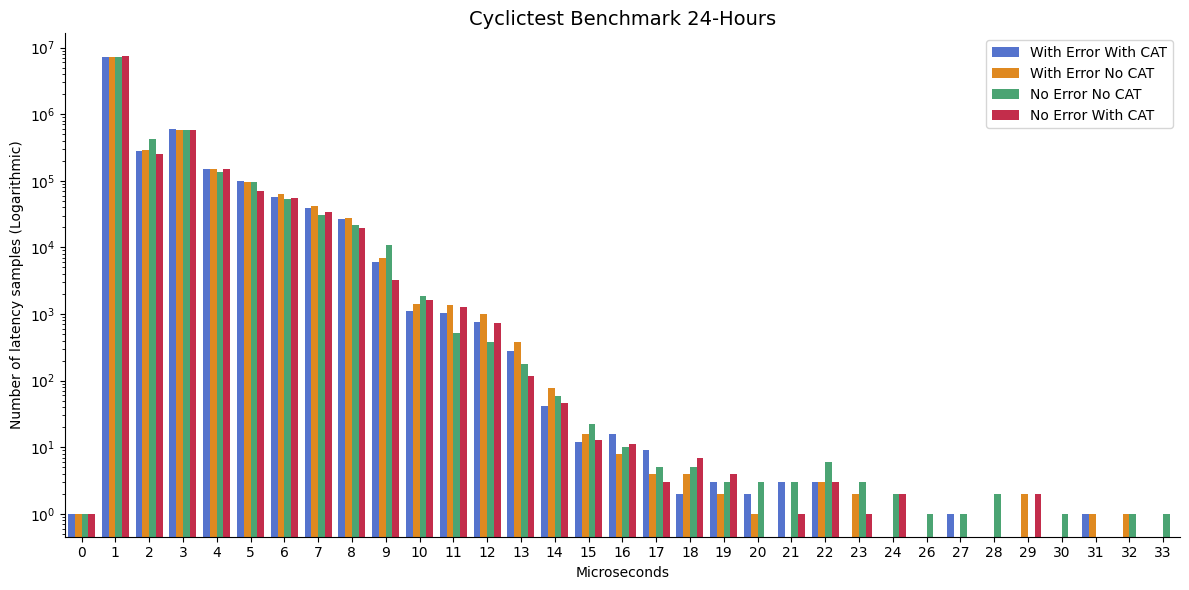

In [19]:

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=combined,
    x='Microseconds',
    y='Count',
    hue='Mode',
    palette = ['royalblue', 'darkorange', 'mediumseagreen', 'crimson'],
    dodge=True
)

plt.yscale('log')
plt.title('Cyclictest Benchmark 24-Hours', fontsize=14)
plt.xlabel('Microseconds')
plt.ylabel('Number of latency samples (Logarithmic)')
sns.despine()
plt.legend(title=None)
plt.tight_layout()
plt.show()